# Phase 1 Smoke Test
Verify that `diffusion_lab` imports correctly and that datasets + network produce sensible shapes.

In [1]:
import sys, pathlib
# Make sure the library is on the path if not installed with pip install -e .
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1  Datasets

spiral        shape=(10000, 2)  mean=[ 0. -0.]  std=[1. 1.]
moons         shape=(10000, 2)  mean=[ 0. -0.]  std=[1. 1.]
checkerboard  shape=(10000, 2)  mean=[-0. -0.]  std=[1. 1.]


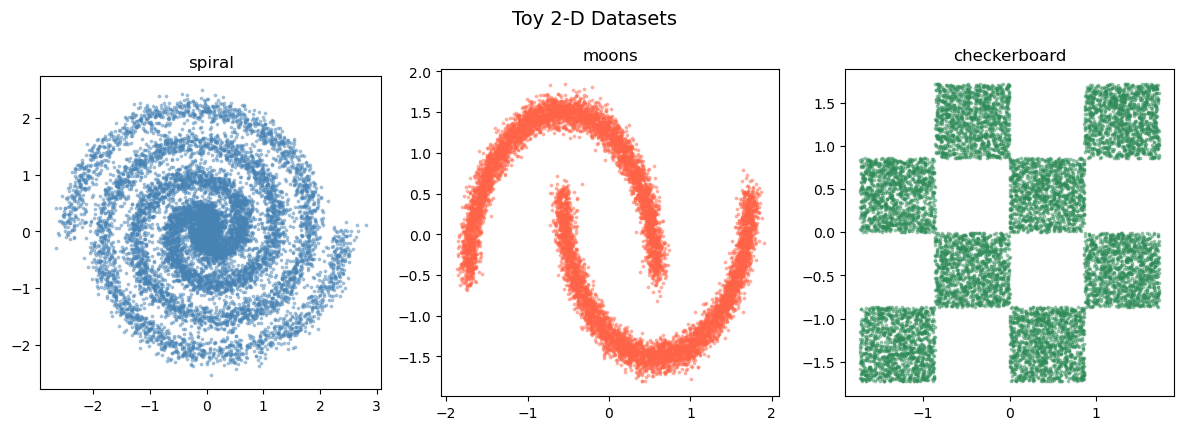

In [5]:
from diffusion_lab.data import make_dataset, DATASETS

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['steelblue', 'tomato', 'seagreen']

for ax, name, c in zip(axes, DATASETS, colors):
    xy = make_dataset(name, n=10000, seed=0)
    ax.scatter(xy[:, 0], xy[:, 1], s=3, alpha=0.4, c=c)
    ax.set_title(name)
    ax.set_aspect('equal')
    print(f'{name:12s}  shape={xy.shape}  mean={xy.mean(0).round(3)}  std={xy.std(0).round(3)}')

plt.suptitle('Toy 2-D Datasets', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 2  DataLoader

In [6]:
from diffusion_lab.data import get_dataloader

loader = get_dataloader('checkerboard', n=10000, batch_size=128)
batch, = next(iter(loader))
print(f'Batch shape: {batch.shape}  dtype: {batch.dtype}')  # expect (128, 2) float32

Batch shape: torch.Size([128, 2])  dtype: torch.float32


## 3  TimeMLP forward pass

In [7]:
import torch
from diffusion_lab.nn import TimeMLP, SinusoidalEmbedding

net = TimeMLP(in_dim=2, out_dim=2, hidden=128, depth=4, time_embed_dim=64)
print(f'TimeMLP parameters: {sum(p.numel() for p in net.parameters()):,}')

x = torch.randn(32, 2)
t = torch.rand(32)   # t in [0, 1]
out = net(x, t)
print(f'Input shape : {x.shape}')
print(f'Output shape: {out.shape}')   # expect (32, 2)

# sinusoidal embedding test
emb = SinusoidalEmbedding(dim=64)
e = emb(t)
print(f'Embedding shape: {e.shape}')   # expect (32, 64)

TimeMLP parameters: 41,858
Input shape : torch.Size([32, 2])
Output shape: torch.Size([32, 2])
Embedding shape: torch.Size([32, 64])


## 4  Trainer (mini training loop)

In [8]:
import torch.nn as nn
from diffusion_lab.training import Trainer

class ToyModel(nn.Module):
    """Dummy model: predict the noise added to x."""
    def __init__(self):
        super().__init__()
        self.net = TimeMLP(2, 2, hidden=64, depth=3, time_embed_dim=32)
    def loss(self, x0):
        t = torch.rand(x0.shape[0], device=x0.device)
        eps = torch.randn_like(x0)
        xt = x0 + eps
        pred = self.net(xt, t)
        return ((pred - eps) ** 2).mean()

model = ToyModel()
ldr   = get_dataloader('moons', n=10000, batch_size=64)
trainer = Trainer(model, ldr, lr=1e-3, device='cpu')

losses = trainer.train(n_steps=200, log_every=50)
print(f'Initial loss: {losses[0]:.4f}   Final loss: {losses[-1]:.4f}')

Training:   0%|          | 0/200 [00:00<?, ?it/s]

Initial loss: 0.9985   Final loss: 0.4135


## 5  Loss curve

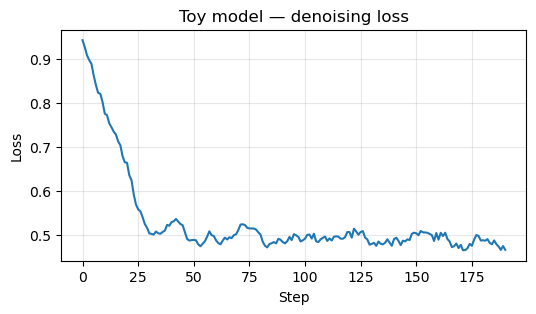

In [9]:
from diffusion_lab.utils import plot_loss_curve

plot_loss_curve(losses, smooth=10, title='Toy model — denoising loss')
plt.show()

## 6  Viz helpers

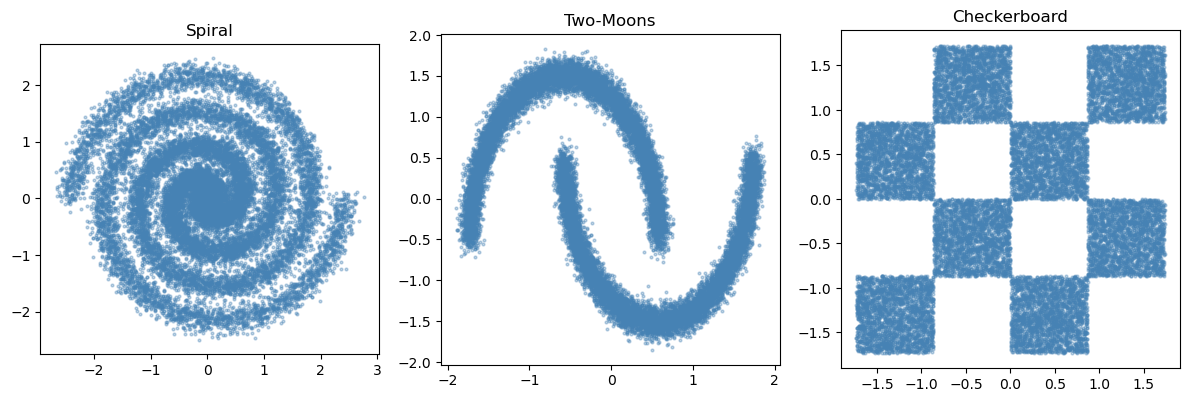


=== Phase 1 complete ===


In [10]:
from diffusion_lab.utils import compare_panels

spiral = make_dataset('spiral', n=20000)
moons  = make_dataset('moons',  n=20000)
chkbd  = make_dataset('checkerboard', n=20000)

compare_panels(spiral, moons, chkbd,
               titles=['Spiral', 'Two-Moons', 'Checkerboard'])
plt.show()

print('\n=== Phase 1 complete ===')